# **1. Demo Básica de Retrieval-Augmented Generation (BasicRAG) con Gemini:**

## **Preparación del entorno:**

In [1]:
# ================= DEMO RAG CON GEMINI ==================
!pip install chromadb sentence-transformers google-generativeai

import os
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
import chromadb
from google.colab import files

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.8/510.8 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 122.1 MB/s e

In [7]:
!pip -q install nltk rouge-score matplotlib seaborn bert-score pandas transformers --upgrade


In [20]:
#Metricas
from nltk.tokenize import word_tokenize

def compute_bleu(candidate: str, references: list, weights=(0.25, 0.25, 0.25, 0.25)):
    """
    Compute BLEU score for one candidate against one or more references.
    - candidate: string
    - references: list of strings
    - weights: tuple for 1- to 4-gram weights (default uniform)
    """
    cand_tokens = word_tokenize(candidate.lower())
    ref_tokens_list = [word_tokenize(r.lower()) for r in references]
    smoothie = SmoothingFunction().method1
    score = sentence_bleu(ref_tokens_list, cand_tokens, weights=weights, smoothing_function=smoothie)
    return score

def compute_rouge(ref: str, pred: str):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    scores = scorer.score(ref, pred)
    return {k: {'precision': v.precision, 'recall': v.recall, 'f1': v.fmeasure} for k, v in scores.items()}

# Demo
candidate = 'The cat is on the mat'
references = ['There is a cat on the mat', 'The cat sits on the mat']
print('BLEU demo:', compute_bleu(candidate, references))
print('ROUGE demo:', compute_rouge(references[0], candidate))

BLEU demo: 0.2659147948472494
ROUGE demo: {'rouge1': {'precision': 0.8333333333333334, 'recall': 0.7142857142857143, 'f1': 0.7692307692307692}, 'rougeL': {'precision': 0.6666666666666666, 'recall': 0.5714285714285714, 'f1': 0.6153846153846153}}


In [8]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
try:
    from bert_score import score
    bertscore_available = True
    print('BERTScore available!')
except ImportError:
    print('BERTScore not available - will use simulated scores')
    bertscore_available = False
nltk.download('punkt')
nltk.download('punkt_tab')
print('Setup complete.')

BERTScore available!
Setup complete.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
os.environ["GEMINI_API_KEY"] = ""
genai.configure(api_key=os.environ["GEMINI_API_KEY"])

In [10]:
# ========= 2. SUBIR ARCHIVO =========
print("Sube un archivo de texto con información (ej: cuantica.txt)")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
with open(file_name, "r", encoding="utf-8") as f:
    text = f.read()


Sube un archivo de texto con información (ej: cuantica.txt)


Saving cuantica.txt to cuantica.txt


In [11]:
# ========= 3. FUNCIÓN DE CHUNKING =========
def chunk_text(text, chunk_size=80, overlap=20):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)
    return chunks

docs = chunk_text(text, chunk_size=80, overlap=20)

print("Ejemplo de 3 chunks creados:")
for c in docs[:3]:
    print("-", c, "\n")

Ejemplo de 3 chunks creados:
- Max Planck introdujo en 1900 la idea de que la energía no se emite de manera continua, sino en cuantos discretos. Este fue el inicio de la teoría cuántica. Albert Einstein en 1905 explicó el efecto fotoeléctrico utilizando el concepto de cuantos de luz, lo que posteriormente llamó fotones. Niels Bohr en 1913 propuso su modelo atómico, donde los electrones orbitaban en niveles de energía cuantizados alrededor del núcleo. Werner Heisenberg enunció en 1927 el principio de incertidumbre, que indica 

- orbitaban en niveles de energía cuantizados alrededor del núcleo. Werner Heisenberg enunció en 1927 el principio de incertidumbre, que indica que no es posible conocer con precisión la posición y el momento de una partícula al mismo tiempo. Erwin Schrödinger desarrolló la ecuación de onda en 1926, fundamental para describir el comportamiento cuántico de las partículas. Richard Feynman contribuyó a la electrodinámica cuántica y popularizó el uso de diagramas que

In [12]:
# ========= 4. CREAR EMBEDDINGS Y BASE VECTORIAL =========
embedder = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.Client()
collection = client.get_or_create_collection("physics_chunks")

embeddings = embedder.encode(docs).tolist()
for i, d in enumerate(docs):
    collection.add(documents=[d], embeddings=[embeddings[i]], ids=[str(i)])



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
# ========= 5. CONSULTA Y RETRIEVAL =========
# 👉 Aquí puedes cambiar la pregunta y experimentar ========================================
# Ejemplos para probar:
# query = "¿Qué explica la teoría de la relatividad?"
# query = "¿Cuál fue un hecho clave en la independencia de Colombia?"
query = "¿Qué científico propuso un modelo atómico en 1913?"
q_embed = embedder.encode([query]).tolist()
results = collection.query(query_embeddings=q_embed, n_results=3)
retrieved_context = " ".join(results['documents'][0])

print("\n🔹 Chunks relevantes recuperados:")
for doc in results['documents'][0]:
    print("-", doc)



🔹 Chunks relevantes recuperados:
- Max Planck introdujo en 1900 la idea de que la energía no se emite de manera continua, sino en cuantos discretos. Este fue el inicio de la teoría cuántica. Albert Einstein en 1905 explicó el efecto fotoeléctrico utilizando el concepto de cuantos de luz, lo que posteriormente llamó fotones. Niels Bohr en 1913 propuso su modelo atómico, donde los electrones orbitaban en niveles de energía cuantizados alrededor del núcleo. Werner Heisenberg enunció en 1927 el principio de incertidumbre, que indica
- orbitaban en niveles de energía cuantizados alrededor del núcleo. Werner Heisenberg enunció en 1927 el principio de incertidumbre, que indica que no es posible conocer con precisión la posición y el momento de una partícula al mismo tiempo. Erwin Schrödinger desarrolló la ecuación de onda en 1926, fundamental para describir el comportamiento cuántico de las partículas. Richard Feynman contribuyó a la electrodinámica cuántica y popularizó el uso de diagramas 

In [15]:

# ========= 6. GEMINI PARA RESPONDER CON CONTEXTO =========
model = genai.GenerativeModel("models/gemini-1.5-flash-latest")

prompt = f"Basándote en el siguiente contexto, responde la pregunta y añade una breve explicación adicional desde tu conocimiento si es relevante:.\n\nContexto:\n{retrieved_context}\n\nPregunta: {query}"

response = model.generate_content(prompt)

print("\n🔹 Respuesta generada por Gemini:")
print(response.text)


🔹 Respuesta generada por Gemini:
Niels Bohr propuso un modelo atómico en 1913.  Este modelo postulaba que los electrones orbitan el núcleo atómico en órbitas específicas con niveles de energía cuantizados,  a diferencia de los modelos anteriores que permitían órbitas con cualquier nivel de energía.  Este fue un paso crucial en el desarrollo de la mecánica cuántica, aunque posteriormente fue reemplazado por modelos más precisos y completos.



In [22]:
## Gemini Responder sin contexto

model = genai.GenerativeModel("models/gemini-1.5-flash-latest")

prompt2 = f"Responde la pregunta y añade una breve explicación adicional desde tu conocimiento si es relevante:.\n\nPregunta: {query}"

response2 = model.generate_content(prompt2)

print("\n🔹 Respuesta generada por Gemini:")
print(response2.text)



🔹 Respuesta generada por Gemini:
Niels Bohr propuso un modelo atómico en 1913.

**Explicación adicional:**  El modelo atómico de Bohr mejoró significativamente el modelo de Rutherford.  Mientras que el modelo de Rutherford describía el átomo con un núcleo denso y positivo rodeado por electrones, no explicaba la estabilidad del átomo (los electrones, según la física clásica, deberían caer en el núcleo). Bohr incorporó la teoría cuántica de Planck, postulando que los electrones orbitan el núcleo en niveles de energía específicos y discretos.  Sólo pueden saltar entre estos niveles absorbiendo o emitiendo fotones de energía específica, lo que explicaba el espectro de emisión de hidrógeno.  Aunque el modelo de Bohr fue posteriormente reemplazado por modelos más complejos y precisos (como el modelo mecánico cuántico), fue un paso crucial en la comprensión de la estructura atómica y sentó las bases para la mecánica cuántica.



## Metricas para BasicRag con Gemeini

ROUGE for Summary A: {'rouge1': {'precision': 0.3146067415730337, 'recall': 0.7466666666666667, 'f1': 0.4426877470355731}, 'rougeL': {'precision': 0.21348314606741572, 'recall': 0.5066666666666667, 'f1': 0.30039525691699603}}
ROUGE for Summary B: {'rouge1': {'precision': 0.3231707317073171, 'recall': 0.7066666666666667, 'f1': 0.4435146443514645}, 'rougeL': {'precision': 0.2073170731707317, 'recall': 0.4533333333333333, 'f1': 0.2845188284518828}}
BLEU Con Contexto: 0.11846632817300808
BLEU Sin Contexto: 0.11376256026924073


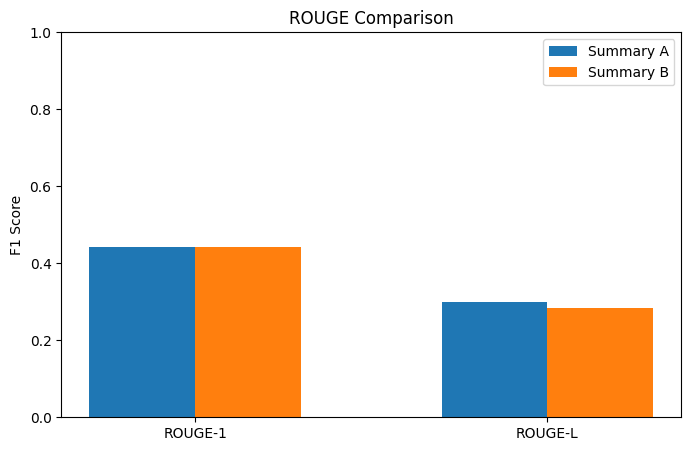

In [24]:
source_text = """Niels Bohr propuso un modelo atómico en 1913. En este modelo, los electrones orbitaban alrededor del núcleo en niveles de energía cuantizados o discretos, lo que significa que solo podían existir en ciertas órbitas permitidas con energías específicas. Este modelo fue revolucionario porque explicaba la estabilidad del átomo y los espectros de emisión del hidrógeno, resolviendo problemas que el modelo anterior de Rutherford no podía explicar."""
summary_a = response.text
summary_b = response2.text

scores_a = compute_rouge(source_text, summary_a)
scores_b = compute_rouge(source_text, summary_b)
print('ROUGE for Summary A:', scores_a)
print('ROUGE for Summary B:', scores_b)

bleu_a = compute_bleu(summary_a, [source_text])
bleu_b = compute_bleu(summary_b, [source_text])
print('BLEU Con Contexto:', bleu_a)
print('BLEU Sin Contexto:', bleu_b)



# Simple visualization for F1
labels = ['ROUGE-1', 'ROUGE-L']
a_f1 = [scores_a['rouge1']['f1'], scores_a['rougeL']['f1']]
b_f1 = [scores_b['rouge1']['f1'], scores_b['rougeL']['f1']]
x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar([i-0.15 for i in x], a_f1, width=0.3, label='Summary A')
plt.bar([i+0.15 for i in x], b_f1, width=0.3, label='Summary B')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel('F1 Score')
plt.title('ROUGE Comparison')
plt.legend()
plt.show()

# 2. **GraphRAG con Gemini + Neo4j: Consultando Grafos de Conocimiento:**

En este ejemplo usamos Gemini para extraer triples semánticos del texto (por ejemplo: (Elon Musk, fundó, Tesla)).

Luego esos triples se guardan en Neo4j, una base de datos orientada a grafos.
Después, podemos hacer consultas usando Cypher, el lenguaje de Neo4j, y finalmente Gemini genera una respuesta en lenguaje natural usando la información consultada.

Esto permite transformar un texto plano en un grafo de conocimiento consultable, lo que es muy útil para preguntas complejas que requieren relaciones entre entidades.

## **Preparación del entorno:**

Antes de ejecutar el código:

1. **Cuenta en Neo4j AuraDB (gratis): https://neo4j.com/product/auradb/**

- Ir a Neo4j AuraDB Free.

- Crear una cuenta y una base de datos gratuita.

- Copiar los datos de conexión (URI, Usuario, Contraseña).

**⚠️ Este paso, al igual que la creación de la API Key de Gemini, solo será necesario si las credenciales ya incluidas en el código no funcionan.
De esta manera, cada estudiante tendrá la opción de usar sus propias credenciales y su propia base de datos personalizada en caso de que sea necesario.**

2. **Nuevamente tener presente los archivos disponibles en Drive:https://drive.google.com/drive/folders/1uF7-oSMpzSdID2ltQf9NsU5Snf16fHfx?usp=sharing**

- cuantica.txt → introducción a la física cuántica. **(Usado en al demo en clase)**.

- innovadores.txt → introducción a la física cuántica. **(Usado en al demo en clase)**.

- historia_Colombia.txt → texto sobre historia de Colombia.

- historia_internet.txt → documento con explicación básica de Einstein.

👉 **Suban uno de estos archivos (o el suyo propio) cuando el código lo pida.****

## **Snippets de Cypher para practicar**

Los estudiantes pueden reemplazar el query y la pregunta con estos ejemplos (COPIAR Y PEGAR EN EL BLOQUE DE CODIGO DEL GRAPHRAG):

### **Para el documento innovadores.txt disponible en google drive:** ¿Cuáles son las empresas fundadas por Elon Musk y por Steve Jobs, a qué se dedica cada una y por qué es importante lo que hacen?


In [34]:
cypher_query = """
MATCH (p:Entidad)-[r:RELACION]->(c:Entidad)
RETURN p.name AS persona, r.tipo AS relacion, c.name AS compania
"""

### **Para el documento hisotria_internet.txt disponible en google drive:** ¿Cuál fue la importancia de Tim Berners-Lee en la historia de Internet?

In [35]:
cypher_query = """
MATCH (a:Entidad)-[r:RELACION]->(b:Entidad)
WHERE a.name = "Tim Berners-Lee"
RETURN a.name AS a, r.tipo AS relacion, b.name AS b
"""

In [36]:
# ================== INSTALACIÓN ==================
!pip install neo4j google-generativeai

import os
from neo4j import GraphDatabase
import google.generativeai as genai
from google.colab import files

# ================== CONFIGURACIÓN ==================
# 👉 API Key de Gemini (puede usar la nuestra o crear la suya en https://aistudio.google.com/)
os.environ["GEMINI_API_KEY"] = ""
genai.configure(api_key=os.environ["GEMINI_API_KEY"])

# 👉 Configura Neo4j con tus propios datos (SOLO si falla la configuración por defecto del Colab)
NEO4J_URI = ""
NEO4J_USER = ""
NEO4J_PASSWORD = ""

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# ================== SUBIR DOCUMENTO ==================
print("Sube un archivo de texto con información (ej: innovadores.txt)")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
with open(file_name, "r", encoding="utf-8") as f:
    text = f.read()

# ================== EXTRAER TRIPLES CON GEMINI ==================
model = genai.GenerativeModel("models/gemini-1.5-flash-latest")

prompt = f"""
Extrae relaciones del siguiente texto en formato de triples:
(SUJETO, RELACIÓN, OBJETO).
Texto:
{text}
"""

response = model.generate_content(prompt)
print("🔹 Triples extraídos por Gemini:")
print(response.text)

# ================== GUARDAR TRIPLES EN NEO4J ==================
def insert_triple(tx, s, r, o):
    query = """
    MERGE (a:Entidad {name: $s})
    MERGE (b:Entidad {name: $o})
    MERGE (a)-[rel:RELACION {tipo: $r}]->(b)
    """
    tx.run(query, s=s, r=r, o=o)

triples = []
for line in response.text.split("\n"):
    if "(" in line and ")" in line:
        line = line.strip("()")
        parts = [p.strip() for p in line.split(",")]
        if len(parts) == 3:
            triples.append(parts)

with driver.session() as session:
    for s, r, o in triples:
        session.write_transaction(insert_triple, s, r, o)

print(f"✅ Se insertaron {len(triples)} triples en Neo4j")

# ================== CONSULTA AL GRAFO ==================
def query_graph(query):
    with driver.session() as session:
        result = session.run(query)
        return [dict(r) for r in result]

# AQUI PUEDEN CAMBIAR LAS QUERY POR LOS EJEMPLOS DE ARRIBA ============================== ⏰⏰⏰ =============================
cypher_query = """
MATCH (p:Entidad)-[r:RELACION]->(c:Entidad)
RETURN p.name AS persona, r.tipo AS relacion, c.name AS compania
"""

results = query_graph(cypher_query)

print("\n🔹 Resultados de la consulta Cypher:")
for r in results:
    print(f"{r['persona']} {r['relacion']} {r['compania']}")

# ================== GEMINI PARA RESPUESTA FINAL ==================
context = "\n".join([f"{r['persona']} {r['relacion']} {r['compania']}" for r in results])

# AQUI PUEDEN CAMBIAR LAS PREGUNTAS POR LOS EJEMPLOS DE ARRIBA ============================== ⏰⏰⏰ =============================

final_prompt = f"""
Basándote en el siguiente contexto de un grafo de conocimiento, responde la pregunta y proporciona contexto:

Contexto:
{context}

Pregunta:  ¿Cuáles son las empresas fundadas por Elon Musk y por Steve Jobs, a qué se dedica cada una y por qué es importante lo que hacen?
"""

response_final = model.generate_content(final_prompt)
print("\n🔹 Respuesta generada por Gemini:")
print(response_final.text)


Sube un archivo de texto con información (ej: innovadores.txt)


Saving innovadores.txt to innovadores (3).txt
🔹 Triples extraídos por Gemini:
Aquí hay una lista de triples (SUJETO, RELACIÓN, OBJETO) extraídas del texto, intentando mantener la precisión y la variedad de las relaciones:


* **(Elon Musk, fundó, Tesla)**
* **(Tesla, tipo_de_compañia, fabricante de automóviles eléctricos)**
* **(Tesla, se_dedica_a, soluciones de energía renovable)**
* **(Elon Musk, fundó, SpaceX)**
* **(SpaceX, tipo_de_empresa, empresa de exploración espacial)**
* **(SpaceX, desarrolla, cohetes)**
* **(SpaceX, desarrolla, satélites)**
* **(Elon Musk, participó_en_la_creación_de, PayPal)**
* **(PayPal, tipo_de_sistema, sistema de pagos en línea)**
* **(PayPal, revolucionó, transacciones digitales)**
* **(Steve Jobs, fue_cofundador_de, Apple)**
* **(Apple, tipo_de_empresa, empresa reconocida por productos tecnológicos innovadores)**
* **(Apple, desarrolló, iPhone)**
* **(Apple, desarrolló, iPad)**
* **(Apple, desarrolló, MacBook)**
* **(Apple, fue_clave_en, desarrollo de

/tmp/ipython-input-1637113288.py:62: DeprecationWarning: write_transaction has been renamed to execute_write
  session.write_transaction(insert_triple, s, r, o)


✅ Se insertaron 34 triples en Neo4j

🔹 Resultados de la consulta Cypher:
Aquí tienes las relaciones extraídas del texto en formato de triples (SUJETO RELACIÓN OBJETO):
* (Elon Musk fundó Tesla
* (Tesla tipo_de_compañía fabricante de automóviles eléctricos
* (Tesla ofrece soluciones de energía renovable
* (Tesla se_dedica_a soluciones de energía renovable
* (Elon Musk fundó SpaceX
* (SpaceX tipo_de_empresa empresa de exploración espacial
* (SpaceX desarrolla cohetes
* (SpaceX desarrolla satélites
* (Elon Musk participó_en_la_creación_de PayPal
* (Elon Musk participó_en_la_creación PayPal
* (PayPal tipo_de_sistema sistema de pagos en línea
* (PayPal tipo_de_servicio sistema de pagos en línea
* (PayPal revolucionó transacciones digitales
* (Steve Jobs fue_cofundador_de Apple
* (Steve Jobs cofundó Apple
* (Apple reconocida_por productos tecnológicos innovadores
* (Apple reconocido_por productos tecnológicos innovadores
* (Apple desarrolló iPhone
* (Apple desarrolló iPad
* (Apple desarrolló

In [33]:
#Sin contexto
final_prompt2 = f"""
responde la pregunta y proporciona contexto:

Pregunta:  ¿Cuáles son las empresas fundadas por Steve Jobs y por Elon Musk, a qué se dedica cada una y por qué es importante lo que hacen?
"""

response_final2 = model.generate_content(final_prompt2)
print("\n🔹 Respuesta generada por Gemini:")
print(response_final2.text)


🔹 Respuesta generada por Gemini:
Steve Jobs y Elon Musk son dos figuras icónicas del mundo de la tecnología, aunque con enfoques y legados distintos.  Sus empresas han tenido un impacto profundo en la sociedad, aunque de maneras diferentes.

**Steve Jobs:**

Si bien estuvo involucrado en varias empresas, las más significativas fundadas o cofundadas por Steve Jobs son:

* **Apple Inc.:**  Es una multinacional estadounidense que diseña y fabrica productos electrónicos de consumo, software y servicios online.  Sus productos icónicos incluyen el iPhone, el iPad, las computadoras Macintosh y el Apple Watch.  
    * **A qué se dedica:**  Diseño, fabricación y venta de hardware y software de alta calidad, con un fuerte énfasis en la experiencia del usuario.
    * **Importancia:** Apple ha revolucionado la industria tecnológica con sus diseños innovadores, su integración de hardware y software, y la creación de ecosistemas cerrados pero altamente eficientes.  Han popularizado la computación p

## Metricas para GraphRAG


ROUGE for Summary A: {'rouge1': {'precision': 0.5854922279792746, 'recall': 0.6348314606741573, 'f1': 0.6091644204851752}, 'rougeL': {'precision': 0.41968911917098445, 'recall': 0.4550561797752809, 'f1': 0.4366576819407008}}
ROUGE for Summary B: {'rouge1': {'precision': 0.19596541786743515, 'recall': 0.7640449438202247, 'f1': 0.3119266055045872}, 'rougeL': {'precision': 0.11527377521613832, 'recall': 0.449438202247191, 'f1': 0.18348623853211007}}
BLEU Con Contexto: 0.24701982249769572
BLEU Sin Contexto: 0.056264135595598105


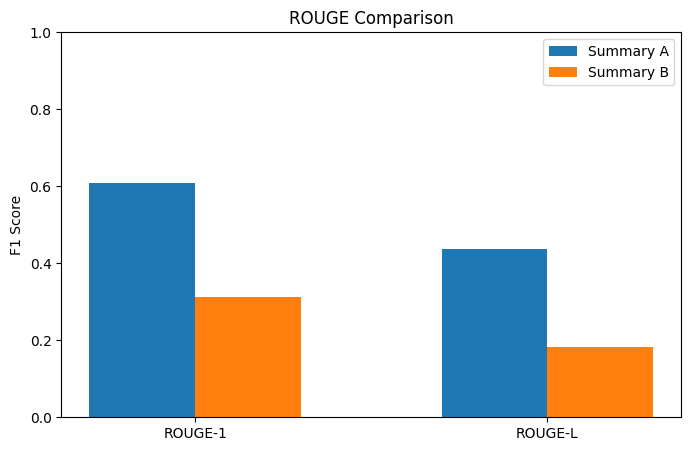

In [37]:
source_text = """Las empresas fundadas por estos emprendedores son:

**Elon Musk:**
- Tesla: Se dedica a la fabricación de automóviles eléctricos y soluciones de energía renovable. Es importante porque acelera la transición mundial hacia el transporte sostenible y la energía limpia, ayudando a combatir el cambio climático.
- SpaceX: Empresa de exploración espacial que desarrolla cohetes y satélites. Su importancia radica en hacer el acceso al espacio más económico y eficiente, con el objetivo de hacer a la humanidad una especie multiplanetaria.
- PayPal: Sistema de pagos en línea que revolucionó las transacciones digitales, facilitando los pagos electrónicos seguros y haciendo el comercio en línea más accesible globalmente.

**Steve Jobs:**
- Apple: Empresa reconocida por sus productos tecnológicos innovadores como el iPhone, iPad y MacBook. Apple ha sido clave en el desarrollo de la industria de los dispositivos inteligentes, transformando cómo interactuamos con la tecnología y estableciendo nuevos estándares de diseño e interfaz de usuario que han influido en toda la industria tecnológica."""

summary_a = response_final.text
summary_b = response_final2.text

scores_a = compute_rouge(source_text, summary_a)
scores_b = compute_rouge(source_text, summary_b)
print('ROUGE for Summary A:', scores_a)
print('ROUGE for Summary B:', scores_b)

bleu_a = compute_bleu(summary_a, [source_text])
bleu_b = compute_bleu(summary_b, [source_text])
print('BLEU Con Contexto:', bleu_a)
print('BLEU Sin Contexto:', bleu_b)



# Simple visualization for F1
labels = ['ROUGE-1', 'ROUGE-L']
a_f1 = [scores_a['rouge1']['f1'], scores_a['rougeL']['f1']]
b_f1 = [scores_b['rouge1']['f1'], scores_b['rougeL']['f1']]
x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar([i-0.15 for i in x], a_f1, width=0.3, label='Summary A')
plt.bar([i+0.15 for i in x], b_f1, width=0.3, label='Summary B')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel('F1 Score')
plt.title('ROUGE Comparison')
plt.legend()
plt.show()

# 3. **FusionRAG (BM25 + Embeddings)**

En este ejemplo se combina lo mejor de dos enfoques de recuperación de información:

- BM25 (keyword-based): Recupera pasajes basándose en la coincidencia de palabras clave.

- Vector Search (embeddings con ChromaDB): Recupera fragmentos usando similitud semántica.

Ambos resultados se fusionan para obtener un contexto más robusto y completo, que luego se pasa al modelo Gemini para generar una respuesta.

👉 Deben subir un archivo de texto (ej: cuantica.txt, historia_colombia.txt, innovadores.txt o historia_internet.txt) y luego probar con diferentes preguntas modificando el campo query.

## **Preparación del entorno:**

Si ya configuraste los entornos de los ejemplos anteriores, no necesitas hacer nada adicional para este bloque. 🚀

In [ ]:
# ================= DEMO FUSION RAG ==================
!pip install rank_bm25 chromadb sentence-transformers google-generativeai

from rank_bm25 import BM25Okapi
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
import chromadb
import os
from google.colab import files

# ================= CONFIGURACIÓN GEMINI ==================
# 👉 API Key de Gemini (puede usar la nuestra o crear la suya en https://aistudio.google.com/)
os.environ["GEMINI_API_KEY"] = ""
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
model = genai.GenerativeModel("models/gemini-1.5-flash-latest")

# ================= SUBIR DOCUMENTO ==================
print("📂 Sube un archivo de texto con información (ej: cuantica.txt, historia_colombia.txt, etc.)")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
with open(file_name, "r", encoding="utf-8") as f:
    text = f.read()

# ================= CHUNKING ==================
def chunk_text(text, chunk_size=80, overlap=20):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size - overlap)]

docs = chunk_text(text)

# ========= Vector Store (embeddings con ChromaDB)
embedder = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.Client()
collection = client.get_or_create_collection("fusion_chunks")
embeddings = embedder.encode(docs).tolist()
for i, d in enumerate(docs):
    collection.add(documents=[d], embeddings=[embeddings[i]], ids=[str(i)])

# ========= BM25 retriever
tokenized_corpus = [d.split(" ") for d in docs]
bm25 = BM25Okapi(tokenized_corpus)

# ========= Fusion Retrieval
query = "¿Qué científico propuso un modelo atómico en 1913?"
q_embed = embedder.encode([query]).tolist()
results_vector = collection.query(query_embeddings=q_embed, n_results=3)
results_bm25 = bm25.get_top_n(query.split(" "), docs, n=3)

# Fusión (simple: concatenación + eliminación de duplicados)
fusion_results = list(set(results_vector['documents'][0] + results_bm25))
retrieved_context = " ".join(fusion_results)

# ================= GEMINI PARA RESPUESTA FINAL ==================
response = model.generate_content(
    f"Basándote en el siguiente contexto (resultado de fusión de múltiples recuperadores), responde la pregunta y añade explicación:\n\n{retrieved_context}\n\nPregunta: {query}"
)

print("\n🔹 Respuesta generada con FusionRAG:")
print(response.text)


📂 Sube un archivo de texto con información (ej: cuantica.txt, historia_colombia.txt, etc.)


Saving cuantica.txt to cuantica (1).txt

🔹 Respuesta generada con FusionRAG:
Niels Bohr propuso un modelo atómico en 1913.  El texto lo indica explícitamente: "Niels Bohr en 1913 propuso su modelo atómico, donde los electrones orbitaban en niveles de energía cuantizados alrededor del núcleo".  Este modelo fue un paso crucial en el desarrollo de la teoría cuántica, ya que introdujo la idea de que los electrones solo podían ocupar ciertas órbitas con niveles de energía específicos.



In [39]:
response_fusion = model.generate_content(
    f"responde la pregunta y añade explicación:\n\nPregunta: {query}"
)

print("\n🔹 Respuesta generada con FusionRAG:")
print(response_fusion.text)


🔹 Respuesta generada con FusionRAG:
El científico que propuso un modelo atómico en 1913 fue **Niels Bohr**.

**Explicación:**  El modelo atómico de Bohr, propuesto en 1913, fue una mejora significativa sobre el modelo atómico de Rutherford.  Si bien el modelo de Rutherford describió correctamente el núcleo atómico positivo con electrones orbitándolo, no explicaba por qué los electrones no colapsaban en el núcleo debido a la atracción electrostática.  Esto violaba las leyes de la física clásica.

Bohr solucionó este problema introduciendo la idea de que los electrones orbitan el núcleo en **órbitas específicas y cuantizadas**.  Esto significa que los electrones solo podían existir en ciertas órbitas con niveles de energía definidos.  Al absorber energía, un electrón podía saltar a una órbita de mayor energía; al liberar energía (por ejemplo, en forma de fotón), podía caer a una órbita de menor energía.  Este salto entre órbitas explicaba las líneas espectrales discretas observadas en l

## Metricas FusionRAG

ROUGE Con Contexto: {'rouge1': {'precision': 0.6, 'recall': 0.6, 'f1': 0.6}, 'rougeL': {'precision': 0.41333333333333333, 'recall': 0.41333333333333333, 'f1': 0.41333333333333333}}
ROUGE Sin Contexto B: {'rouge1': {'precision': 0.24034334763948498, 'recall': 0.7466666666666667, 'f1': 0.36363636363636365}, 'rougeL': {'precision': 0.15879828326180256, 'recall': 0.49333333333333335, 'f1': 0.24025974025974026}}
BLEU Con Contexto: 0.24388981393138828
BLEU Sin Contexto: 0.06988278527147672


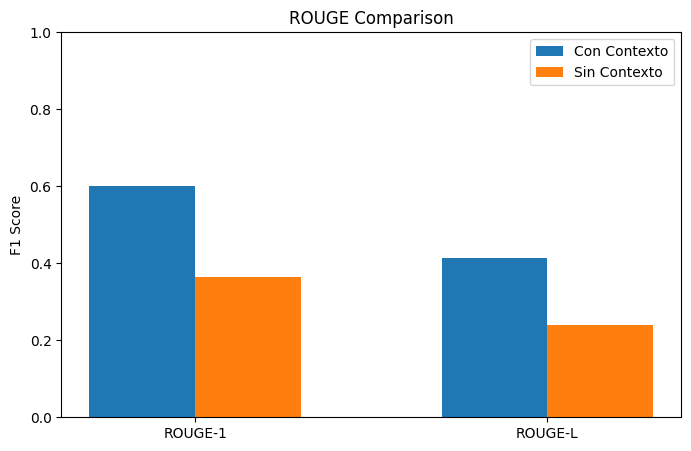

In [42]:
source_text = """Niels Bohr propuso un modelo atómico en 1913. En este modelo, los electrones orbitaban alrededor del núcleo en niveles de energía cuantizados o discretos, lo que significa que solo podían existir en ciertas órbitas permitidas con energías específicas. Este modelo fue revolucionario porque explicaba la estabilidad del átomo y los espectros de emisión del hidrógeno, resolviendo problemas que el modelo anterior de Rutherford no podía explicar."""
summary_a = response.text # con contexto
summary_b = response_fusion.text# sin contexto

scores_a = compute_rouge(source_text, summary_a)
scores_b = compute_rouge(source_text, summary_b)
print('ROUGE Con Contexto:', scores_a)
print('ROUGE Sin Contexto B:', scores_b)

bleu_a = compute_bleu(summary_a, [source_text])
bleu_b = compute_bleu(summary_b, [source_text])
print('BLEU Con Contexto:', bleu_a)
print('BLEU Sin Contexto:', bleu_b)

# Simple visualization for F1
labels = ['ROUGE-1', 'ROUGE-L']
a_f1 = [scores_a['rouge1']['f1'], scores_a['rougeL']['f1']]
b_f1 = [scores_b['rouge1']['f1'], scores_b['rougeL']['f1']]
x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar([i-0.15 for i in x], a_f1, width=0.3, label='Con Contexto')
plt.bar([i+0.15 for i in x], b_f1, width=0.3, label='Sin Contexto')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel('F1 Score')
plt.title('ROUGE Comparison')
plt.legend()
plt.show()